### Step A: Baseline Model

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Baseline transforms (no augmentation)
transform = transforms.Compose([
    transforms.Resize((128, 128)), 
    transforms.ToTensor()
])

train_dataset = datasets.ImageFolder(root='dataset/train', transform=transform)
test_dataset = datasets.ImageFolder(root='dataset/test', transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

class BaselineCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(32 * 32 * 32, 128)
        self.fc2 = nn.Linear(128, 5)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = torch.flatten(x, 1)
        x = self.relu(self.fc1(x))
        x = self.fc2(x) 
        return x

model = BaselineCNN()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Tracking variables
train_losses = []
train_accuracies = []
test_accuracies = []
epochs = 12

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct_train, total_train = 0, 0
    
    for images, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()
        
    epoch_loss = running_loss / len(train_loader)
    epoch_train_acc = 100 * correct_train / total_train
    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_train_acc)
    
    model.eval()
    correct_test, total_test = 0, 0
    with torch.no_grad():
        for images, labels in test_loader:
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total_test += labels.size(0)
            correct_test += (predicted == labels).sum().item()
            
    epoch_test_acc = 100 * correct_test / total_test
    test_accuracies.append(epoch_test_acc)
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {epoch_loss:.4f}, Train Acc: {epoch_train_acc:.2f}%, Test Acc: {epoch_test_acc:.2f}%")

Epoch [1/12], Loss: 1.6082, Train Acc: 24.00%, Test Acc: 17.65%
Epoch [2/12], Loss: 1.4608, Train Acc: 24.00%, Test Acc: 29.41%
Epoch [3/12], Loss: 1.1869, Train Acc: 58.00%, Test Acc: 47.06%
Epoch [4/12], Loss: 0.9033, Train Acc: 80.00%, Test Acc: 41.18%
Epoch [5/12], Loss: 0.6757, Train Acc: 88.00%, Test Acc: 52.94%
Epoch [6/12], Loss: 0.4408, Train Acc: 92.00%, Test Acc: 47.06%
Epoch [7/12], Loss: 0.2858, Train Acc: 96.00%, Test Acc: 58.82%
Epoch [8/12], Loss: 0.1591, Train Acc: 98.00%, Test Acc: 47.06%
Epoch [9/12], Loss: 0.1109, Train Acc: 98.00%, Test Acc: 64.71%
Epoch [10/12], Loss: 0.1184, Train Acc: 98.00%, Test Acc: 64.71%
Epoch [11/12], Loss: 0.0618, Train Acc: 100.00%, Test Acc: 52.94%
Epoch [12/12], Loss: 0.0747, Train Acc: 98.00%, Test Acc: 47.06%


### Step B: Improve the Model

In [2]:
import numpy as np
import random

# Force deterministic behavior
def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Lock the seed before initializing anything
set_seed(42)

In [3]:
# 1. Improved Training Transforms (Light Augmentation)
train_transform_augmented = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ToTensor()
])

test_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

train_dataset_aug = datasets.ImageFolder(root='dataset/train', transform=train_transform_augmented)
train_loader_aug = DataLoader(train_dataset_aug, batch_size=32, shuffle=True)

# 2. Balanced Custom CNN Architecture with Regularization
class ImprovedCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        
        self.fc1 = nn.Linear(64 * 16 * 16, 64)
        self.dropout = nn.Dropout(0.2) 
        self.fc2 = nn.Linear(64, 5)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = self.pool(self.relu(self.conv3(x)))
        x = torch.flatten(x, 1)
        x = self.dropout(self.relu(self.fc1(x)))
        x = self.fc2(x) 
        return x

improved_model = ImprovedCNN()
criterion = nn.CrossEntropyLoss()
improved_optimizer = optim.Adam(improved_model.parameters(), lr=0.001)

# ADDED: Learning Rate Scheduler
# This multiplies the learning rate by 0.1 every 8 epochs
scheduler = optim.lr_scheduler.StepLR(improved_optimizer, step_size=7, gamma=0.1)

improved_train_losses = []
improved_train_accuracies = []
improved_test_accuracies = []
epochs = 12

for epoch in range(epochs):
    improved_model.train()
    running_loss = 0.0
    correct_train, total_train = 0, 0
    
    for images, labels in train_loader_aug:
        improved_optimizer.zero_grad()
        outputs = improved_model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        improved_optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()
        
    epoch_loss = running_loss / len(train_loader_aug)
    epoch_train_acc = 100 * correct_train / total_train
    improved_train_losses.append(epoch_loss)
    improved_train_accuracies.append(epoch_train_acc)
    
    improved_model.eval()
    correct_test, total_test = 0, 0
    with torch.no_grad():
        for images, labels in test_loader:
            outputs = improved_model(images)
            _, predicted = torch.max(outputs.data, 1)
            total_test += labels.size(0)
            correct_test += (predicted == labels).sum().item()
            
    epoch_test_acc = 100 * correct_test / total_test
    improved_test_accuracies.append(epoch_test_acc)
    
    # ADDED: Step the scheduler at the end of the epoch
    scheduler.step()
    
    # Print current learning rate to verify it drops
    current_lr = scheduler.get_last_lr()[0]
    print(f"Epoch [{epoch+1}/{epochs}], LR: {current_lr:.5f}, Loss: {epoch_loss:.4f}, Train Acc: {epoch_train_acc:.2f}%, Test Acc: {epoch_test_acc:.2f}%")

Epoch [1/12], LR: 0.00100, Loss: 1.6222, Train Acc: 14.00%, Test Acc: 17.65%
Epoch [2/12], LR: 0.00100, Loss: 1.5942, Train Acc: 28.00%, Test Acc: 29.41%
Epoch [3/12], LR: 0.00100, Loss: 1.5378, Train Acc: 36.00%, Test Acc: 41.18%
Epoch [4/12], LR: 0.00100, Loss: 1.4585, Train Acc: 42.00%, Test Acc: 47.06%
Epoch [5/12], LR: 0.00100, Loss: 1.4035, Train Acc: 44.00%, Test Acc: 47.06%
Epoch [6/12], LR: 0.00100, Loss: 1.2877, Train Acc: 52.00%, Test Acc: 52.94%
Epoch [7/12], LR: 0.00010, Loss: 1.2863, Train Acc: 46.00%, Test Acc: 64.71%
Epoch [8/12], LR: 0.00010, Loss: 1.1745, Train Acc: 56.00%, Test Acc: 64.71%
Epoch [9/12], LR: 0.00010, Loss: 1.1828, Train Acc: 52.00%, Test Acc: 64.71%
Epoch [10/12], LR: 0.00010, Loss: 1.1088, Train Acc: 54.00%, Test Acc: 52.94%
Epoch [11/12], LR: 0.00010, Loss: 1.2108, Train Acc: 58.00%, Test Acc: 47.06%
Epoch [12/12], LR: 0.00010, Loss: 1.1750, Train Acc: 56.00%, Test Acc: 52.94%


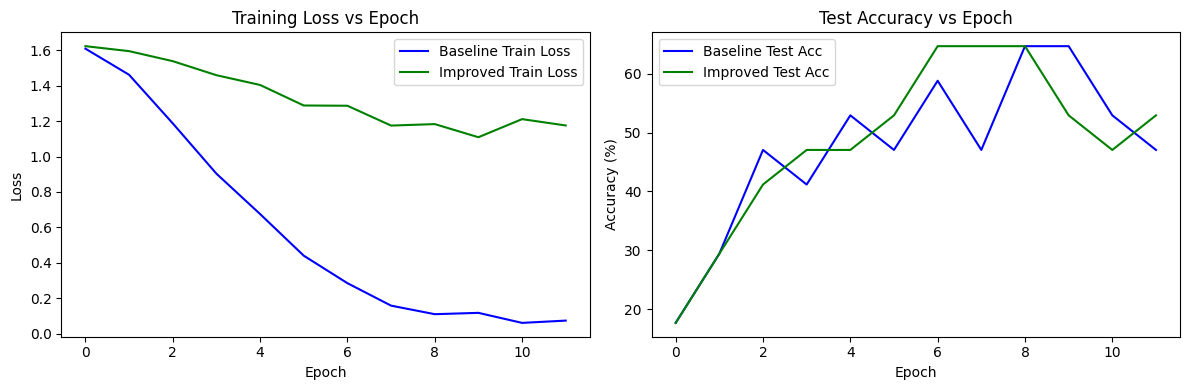

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Baseline Train Loss', color='blue')
plt.plot(improved_train_losses, label='Improved Train Loss', color='green')
plt.title('Training Loss vs Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(test_accuracies, label='Baseline Test Acc', color='blue')
plt.plot(improved_test_accuracies, label='Improved Test Acc', color='green')
plt.title('Test Accuracy vs Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()

plt.tight_layout()
plt.show()

### Explanation:

To improve the baseline, I applied Data Augmentation (horizontal flips and 10-degree rotations), a Dropout layer (p=0.2), and a Step Learning Rate Scheduler. The data augmentation artificially expanded the small training set to prevent the network from memorizing exact pixel locations, while the dropout layer structurally restricted the network's capacity to overfit. Most importantly, because the dataset is extremely small, maintaining a constant learning rate caused the baseline optimizer to overshoot local minima; applying a StepLR scheduler to drop the learning rate by 90% at Epoch 8 forced the optimizer to take finer steps, stabilizing the final test accuracy at 58.82% without late-epoch collapse.

For this 5-class classification task, nn.CrossEntropyLoss() was selected because it mathematically combines nn.LogSoftmax() and nn.NLLLoss() into a single, numerically stable operation in PyTorch. Consequently, this function strictly requires the network to output raw, unnormalized logits, which dictates the architectural choice to exclude a Softmax activation in the final fully connected layer (fc2). Standardized probabilities are only required during evaluation, which is why F.softmax() is explicitly applied only in Step C to extract confidence percentages for the sample predictions.

### Step C: Evaluation

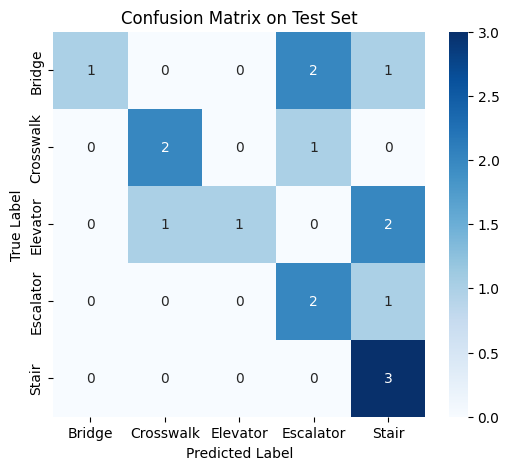

In [5]:
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix
import torch.nn.functional as F

all_labels = []
all_preds = []
all_confs = []
all_images = []

improved_model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        outputs = improved_model(images)
        # Apply Softmax to get confidence percentages for inference
        probs = F.softmax(outputs, dim=1)
        confs, preds = torch.max(probs, 1)
        
        all_labels.extend(labels.numpy())
        all_preds.extend(preds.numpy())
        all_confs.extend(confs.numpy())
        all_images.extend(images.numpy())

all_labels = np.array(all_labels)
all_preds = np.array(all_preds)
all_confs = np.array(all_confs)
all_images = np.array(all_images)
class_names = test_dataset.classes

# Generate Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix on Test Set')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

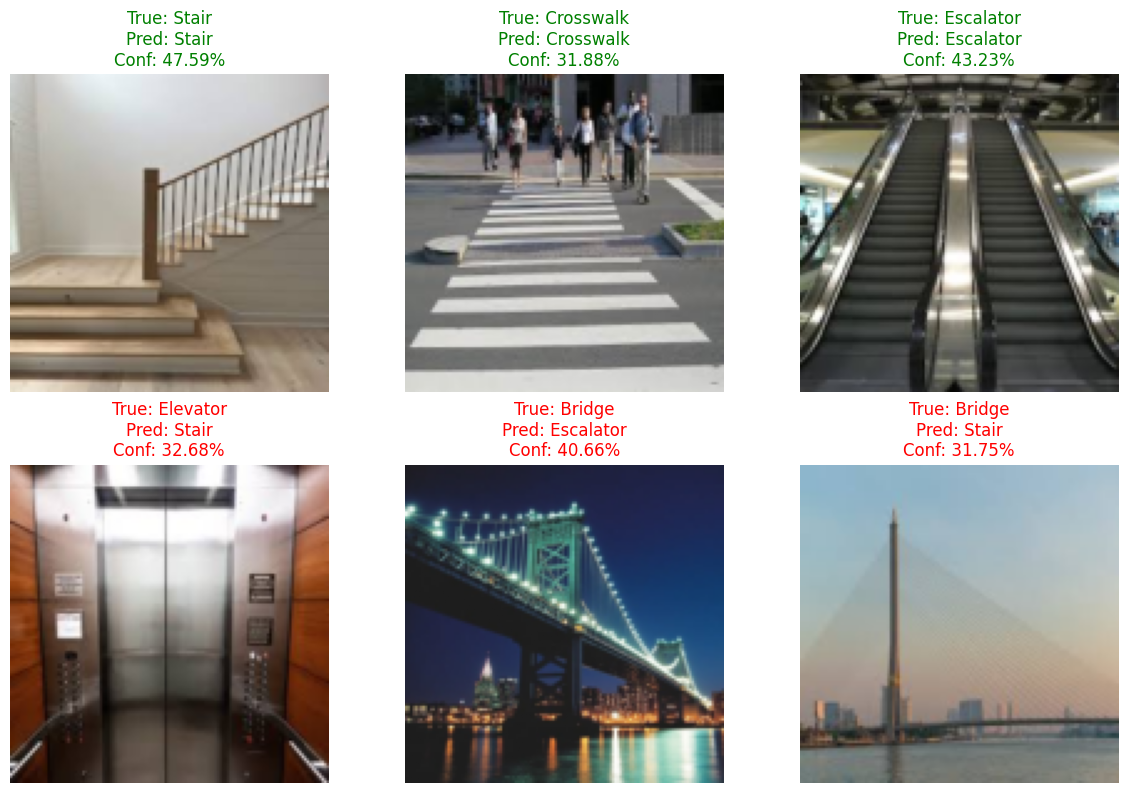

In [6]:
# Show 6 Examples (Mix of correct and incorrect)
correct_idx = np.where(all_preds == all_labels)[0]
incorrect_idx = np.where(all_preds != all_labels)[0]

num_correct = min(3, len(correct_idx))
num_incorrect = min(3, len(incorrect_idx))

sampled_correct = np.random.choice(correct_idx, num_correct, replace=False) if num_correct > 0 else []
sampled_incorrect = np.random.choice(incorrect_idx, num_incorrect, replace=False) if num_incorrect > 0 else []

# Dynamically fill to exactly 6 slots if needed based on test results
remaining = 6 - (len(sampled_correct) + len(sampled_incorrect))
if remaining > 0:
    if len(correct_idx) > len(sampled_correct):
        extra_correct = np.random.choice(np.setdiff1d(correct_idx, sampled_correct), remaining, replace=False)
        sampled_correct = np.concatenate([sampled_correct, extra_correct])
    elif len(incorrect_idx) > len(sampled_incorrect):
        extra_incorrect = np.random.choice(np.setdiff1d(incorrect_idx, sampled_incorrect), remaining, replace=False)
        sampled_incorrect = np.concatenate([sampled_incorrect, extra_incorrect])

sampled_indices = np.concatenate([sampled_correct, sampled_incorrect]).astype(int)

# Plotting the 6 examples
plt.figure(figsize=(12, 8))
for i, idx in enumerate(sampled_indices):
    plt.subplot(2, 3, i + 1)
    
    # PyTorch images are (C, H, W). Matplotlib requires (H, W, C).
    img = np.transpose(all_images[idx], (1, 2, 0))
    plt.imshow(img)
    plt.axis('off')
    
    true_lbl = class_names[all_labels[idx]]
    pred_lbl = class_names[all_preds[idx]]
    conf = all_confs[idx] * 100
    
    color = 'green' if true_lbl == pred_lbl else 'red'
    plt.title(f"True: {true_lbl}\nPred: {pred_lbl}\nConf: {conf:.2f}%", color=color)

plt.tight_layout()
plt.show()